# Regional TC prediction

1. [Read inputs](#1-Read-inputs)
    1. Set prediction year (convention is 2022 for 2022-2023 season).
2. [Enter latest info](#2-Enter-latest-info)
    1. 2021/2022 season TC counts (and onwards). Need dummy variables for SOI and NINO if running before end of Sep.
3. [Check inputs](#3-Check-inputs)
    1. make sure they are as you expect
4. [Run prediction](#4-Run-prediction)

5. Run updated skill cell.


# 0 Python imports

In [1]:
########################
##   IMPORTS ###########
########################

# Generic useful imports
import numpy as np
import pandas as pd
from IPython.display import Markdown as md
import datetime as dt
from pathlib import Path
import sys
# !! Insert your local path here !!
sys.path.insert(0, '/Users/paulgregory/Documents/Scripts/statistical_enso/src')
## local module with:
# Code to read inputs and TC dataset
from prediction import combo_method_SKL, read_nino, read_oni, read_roni, read_soi_file, read_processed_tc

# plotting code for this notepad
import matplotlib.pyplot as plt

%matplotlib inline
# plt.rcParams['figure.figsize'] = (8, 6)
# plt.rcParams['font.size'] = 14
# plt.style.use("fivethirtyeight")

# !! Insert your local path here !!
DATA_DIR = Path('/Users/paulgregory/Documents/Scripts/statistical_enso/data/TC_data')

# 1 Read inputs

1. Set prediction year. 
2. TODO: Option here to use hindcast metrics along with forecast metrics for preliminary seasonal TC outlook

In [2]:
###############################
###   ENTER PREDICTION YEAR ###
###############################
# Change this every year. It will be equal to the start year of the forecast season.
PREDICTION_YEAR=2026

###########################
##   READ INPUTS ##########
###########################

# url="http://www.cpc.ncep.noaa.gov/data/indices/ersst5.nino.mth.91-20.ascii"  # Defunct
# nino = read_nino()
# url="https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt"
# nino = read_oni()
# url="https://www.cpc.ncep.noaa.gov/data/indices/RONI.ascii.txt"
nino = read_roni()

# url="http://www.bom.gov.au/clim_data/IDCKGSH000/soi_monthly.txt"
# need to be on BOM VPN or internal network for this to work
#soi = read_soi(url="https://www.bom.gov.au/clim_data/IDCKGSH000/soi_monthly.txt")

#Updated to read SOI data from disk
soi = read_soi_file( DATA_DIR / 'soi_monthly.txt')

# TC data from historical counts. Read in old 
TC_DIR = str(DATA_DIR / '2021-22')+'/'
tcs = read_processed_tc(TC_folder=TC_DIR)


/Users/paulgregory/Documents/Scripts/statistical_enso/src/prediction.py:206: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  roni_data = pd.read_csv(
/Users/paulgregory/Documents/Scripts/statistical_enso/src/prediction.py:267: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fdata = pd.read_csv(f,skiprows=0,names=columns,delim_whitespace=True, dtype={'dstr':str,region:int})
/Users/paulgregory/Documents/Scripts/statistical_enso/src/prediction.py:267: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fdata = pd.read_csv(f,skiprows=0,names=columns,delim_whitespace=True, dtype={'dstr':str,region:int})
/Users/paulgregory/Documents/Scripts/statistical_enso/src/prediction.py:267: FutureWarning: The 'delim_whitesp

In [3]:
# For finding number per season. Used in old statistical TC outlook.

import pandas as pd
import numpy as np
from shapely.geometry import Point, Polygon

start_year = 2025  # Year that cyclone count is being calculated for. Likely the previous year.
# Load the CSV file, skipping the first 4 metadata rows. Download from https://www.bom.gov.au/cyclone/tropical-cyclone-knowledge-centre/databases/
df = pd.read_csv( DATA_DIR / "IDCKMSTM0S.csv", skiprows=4)

# Convert relevant columns to numeric
df['LAT'] = pd.to_numeric(df['LAT'], errors='coerce')
df['LON'] = pd.to_numeric(df['LON'], errors='coerce')
df['CENTRAL_PRES'] = pd.to_numeric(df['CENTRAL_PRES'], errors='coerce')

# Convert the date column to datetime format
df['TM'] = pd.to_datetime(df['TM'], errors='coerce')

# Create SEASON_START column based on financial year starting July 1st
df['SEASON_START'] = df['TM'].apply(lambda x: x.year if x.month >= 7 else x.year - 1)

# Filter for SEASON_START == 2024 and CENTRAL_PRES < 995
df_filtered = df[(df['SEASON_START'] == start_year) & (df['CENTRAL_PRES'] < 995)].copy()

# Create geometry points from LON and LAT columns
df_filtered['geometry'] = [Point(xy) for xy in zip(df_filtered['LON'], df_filtered['LAT'])]

# Define rectangular regions using shapely Polygons
regions = {
    "Australian region": Polygon([(90, -5), (160, -5), (160, -40), (90, -40)]),
    "Western region": Polygon([(90, -5), (125, -5), (125, -40), (90, -40)]),
    "NW sub-region": Polygon([(105, -5), (130, -5), (130, -25), (105, -25)]),
    "Northern region": Polygon([(125, -5), (142.5, -5), (142.5, -40), (125, -40)]),
    "Eastern region": Polygon([(142.5, -5), (160, -5), (160, -40), (142.5, -40)])
}

# Count unique DISTURBANCE_IDs in each region
region_counts = {}
for region_name, polygon in regions.items():
    in_region = df_filtered['geometry'].apply(lambda point: polygon.covers(point))
    unique_ids = df_filtered[in_region]['DISTURBANCE_ID'].nunique()
    region_counts[region_name] = unique_ids

# Display the results
region_counts

/var/folders/rb/dtr0llb95gq944_n58_wj7j80000gn/T/ipykernel_14702/259124281.py:9: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv( DATA_DIR / "IDCKMSTM0S.csv", skiprows=4)


{'Australian region': 13,
 'Western region': 9,
 'NW sub-region': 7,
 'Northern region': 3,
 'Eastern region': 3}

## 2 Enter latest info

1. File has counts up to 2021/2022 season. We need to manually add the new ones from our GIS method.

In [4]:
#########################
###  ENTER new TCs #####
#########################

#2021 means 2021-22.

tc_new = {
    # 2021 from Craig Earl-Spurr on 20220818
    2021:{
        "AR":11,
        "AR-W":7,
        "AR-NW":7,
        "AR-N":3,
        "AR-E":4,
        "SPO":9,
        "SPO-E":6,
        "SPO-W":5,
    },
    2022:{
        "AR":9,
        "AR-W":6,
        "AR-NW":5,
        "AR-N":2,
        "AR-E":2,
        "SPO":5,
        "SPO-E":5,
        "SPO-W":4,
    },
    2023:{
        "AR":8,
        "AR-W":3,
        "AR-NW":2,
        "AR-N":3,
        "AR-E":3,
        "SPO":9,
        "SPO-E":6,
        "SPO-W":4,
    },
    2024:{
        "AR":11,
        "AR-W":10,
        "AR-NW":7,
        "AR-N":0,
        "AR-E":1,
        "SPO":9,
        "SPO-E":6,
        "SPO-W":4,
    },
    2025:{
        "AR":13,
        "AR-W":9,
        "AR-NW":7,
        "AR-N":3,
        "AR-E":3,
    },    
}

## add to tcs as new rows
for year,row in tc_new.items():
    dtyear=dt.datetime(year,9,1)
    tc_entry = pd.Series(data=row,dtype=int,name=dtyear.strftime('%Y-%m-%d %H:%M:%S'))
    tcs.loc[dtyear] = tc_entry
    
# Need to add preliminary entries if running the code before September data has arrived.
# This is for the preliminary runs. Use the cell above to get running-day SOI values.
# Preliminary NINO values can be obtained through taking the average of the latest Sep weekly value,
# and the monthly values for August and July.

dtyear=dt.datetime(PREDICTION_YEAR,9,1)
# Prelim data
soi.loc[dtyear] = {"date":202509, "SOI":-25.0, "SOI 3m mean":-22.6 }
nino.loc[dtyear] = {"anom":1.80}

In [5]:
# Long paddock SOI analyser

import urllib.request
import pandas as pd
import datetime

# Step 1: Download the file
url = "https://data.longpaddock.qld.gov.au/SeasonalClimateOutlook/SouthernOscillationIndex/SOIDataFiles/DailySOI1933-1992Base.txt"
file_path = str(DATA_DIR / "DailySOI1933-1992Base.txt")
urllib.request.urlretrieve(url, file_path)

# Step 2: Read the file and parse the data
# The file is tab-separated with the columns Date, Year, Month, Day, and SOI.
columns = ["Year", "Day", "Tahiti", "Darwin", "SOI"]

# Load the data into a pandas DataFrame
soi_df = pd.read_csv(file_path, delim_whitespace=True, skiprows=1, names=columns)

# Convert the Date columns to a proper datetime format
# df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])

# Step 3: Calculate the average of the last 30 days
for i in [20, 90]:
    last_30_days = soi_df.tail(i)
    average_soi = last_30_days['SOI'].mean()

    last_day = last_30_days['Day'].iloc[-1]
    last_year = last_30_days['Year'].iloc[-1]   
    
    date_lp = datetime.datetime(last_year, 1, 1) + datetime.timedelta(days=int(last_day) - 1)    
    
    print(f"The average SOI over the last {i} days till {date_lp.day}/{date_lp.month}/{date_lp.year} is: {average_soi:.2f}")


/var/folders/rb/dtr0llb95gq944_n58_wj7j80000gn/T/ipykernel_14702/95499322.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  soi_df = pd.read_csv(file_path, delim_whitespace=True, skiprows=1, names=columns)


The average SOI over the last 20 days till 22/9/2026 is: -25.12
The average SOI over the last 90 days till 22/9/2026 is: -22.15


In [6]:
#########################################
## Subset all data to 1970 onwards ######
#########################################

dt1970 = dt.datetime(1970,9,1)
nino = nino[dt1970:].copy()
soi = soi[dt1970:].copy()
tcs = tcs[dt1970:].copy()

# Just look at 3m mean july aug sep
nino_jas = nino[nino.index.month == 9].copy()['anom']
soi_jas = soi[soi.index.month == 9].copy()['SOI 3m mean']
tcs_sep = tcs[tcs.index.month == 9].copy()

## Check we have data for year we want to predict
if np.sum(nino_jas.index.year == PREDICTION_YEAR) == 0:
    print("ERROR: No NINO METRIC FOR %d"%PREDICTION_YEAR)
    print("     : Maybe turn forecast on, or change prediction year")

if np.sum(soi_jas.index.year == PREDICTION_YEAR) == 0:
    print("ERROR: No SOI METRIC FOR %d"%PREDICTION_YEAR)
    print("     : Maybe turn forecast on, or change prediction year")

## 3 Check inputs

In [7]:
## Check we have useful data.
for df,name in zip([nino_jas,soi_jas,tcs_sep],['nino','soi','tcs']):
    print("===  ",name,"  ===")
    print("  data available from ",df.index[0], " to ", df.index[-1])
    
    print('  last three entries:')
    print(df[-5:])
    print() # breakline
    
    # mini plot of distributions? or timeseries?

===   nino   ===
  data available from  1970-09-01 00:00:00  to  2026-09-01 00:00:00
  last three entries:
date
2022-09-01   -0.94
2023-09-01    0.79
2024-09-01   -0.56
2025-09-01   -0.59
2026-09-01    1.80
Name: anom, dtype: float64

===   soi   ===
  data available from  1970-09-01 00:00:00  to  2026-09-01 00:00:00
  last three entries:
datetime
2022-09-01    12.033333
2023-09-01   -10.200000
2024-09-01    -0.033333
2025-09-01     3.033333
2026-09-01   -22.600000
Name: SOI 3m mean, dtype: float64

===   tcs   ===
  data available from  1970-09-01 00:00:00  to  2025-09-01 00:00:00
  last three entries:
              AR  AR-W  AR-NW  AR-N  AR-E  SPO  SPO-W  SPO-E
date                                                        
2021-09-01  11.0   7.0    7.0   3.0   4.0  9.0    5.0    6.0
2022-09-01   9.0   6.0    5.0   2.0   2.0  5.0    4.0    5.0
2023-09-01   8.0   3.0    2.0   3.0   3.0  9.0    4.0    6.0
2024-09-01  11.0  10.0    7.0   0.0   1.0  9.0    4.0    6.0
2025-09-01  13.0   9.0 

## 4 Run prediction
# This will give you the chance above medians

In [8]:
# outputs for each target will be stored as a list
output_row        = []
# list will have several named entries and be put into a table
output_columns = [
    'region','P(<=median)','P(>median)',
    #'t1','t2','t3',
    'TC mean','TC SD','TC median',
    ]

for target in ['AR','AR-W','AR-N','AR-E','AR-NW','SPO','SPO-W','SPO-E']:
    Y=tcs_sep[target]
    proba_nino, proba_soi = combo_method_SKL(
        X1=nino_jas,
        X2=soi_jas,
        Y=Y,
        prediction_year=PREDICTION_YEAR,
    )
    # bom probability is the mean from two LDAs
    probas = (proba_nino+proba_soi)/2.0
    ## Tercile probability (?)
    #t1,t2,t3 = get_terciles(probas)
    
    ## Mean and std of TC count
    mean = Y.mean()
    std = Y.std()
    median = Y.median()
    
    ## Add row to list
    output_row.append([target,probas[0,0],probas[0,1],
                       #t1,t2,t3,
                       mean,std,median])
    
## Make list of rows into dataframe for easy printing...
df_stats=pd.DataFrame(output_row,columns=output_columns)

# Check output
md("# Prediction for %d"%(PREDICTION_YEAR))
print(df_stats)


  region  P(<=median)  P(>median)    TC mean     TC SD  TC median
0     AR     0.876494    0.123506  11.000000  3.269696       11.0
1   AR-W     0.830313    0.169687   6.660714  2.502920        6.5
2   AR-N     0.616100    0.383900   2.589286  1.345387        2.0
3   AR-E     0.842820    0.157180   3.535714  1.838619        3.0
4  AR-NW     0.873191    0.126809   4.892857  2.068628        5.0
5    SPO     0.439476    0.560524   8.963636  3.260105        9.0
6  SPO-W     0.729426    0.270574   4.363636  1.898963        4.0
7  SPO-E     0.315743    0.684257   6.381818  3.106093        6.0


# 5 For calculating new skill

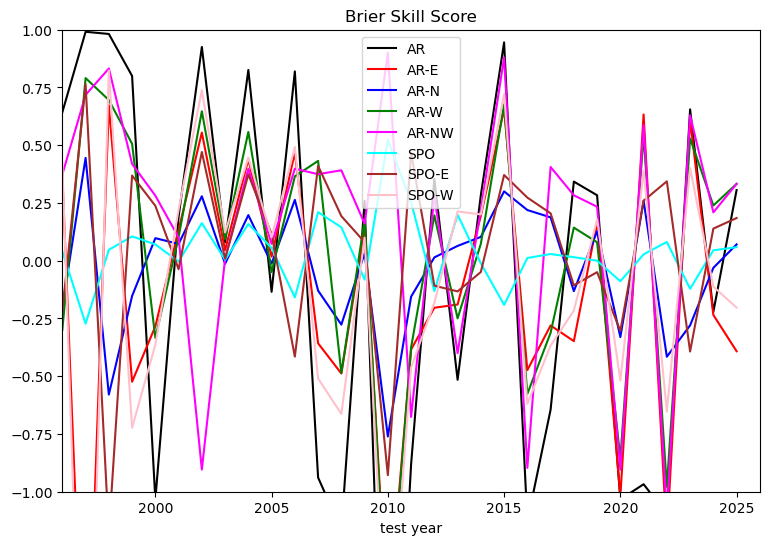

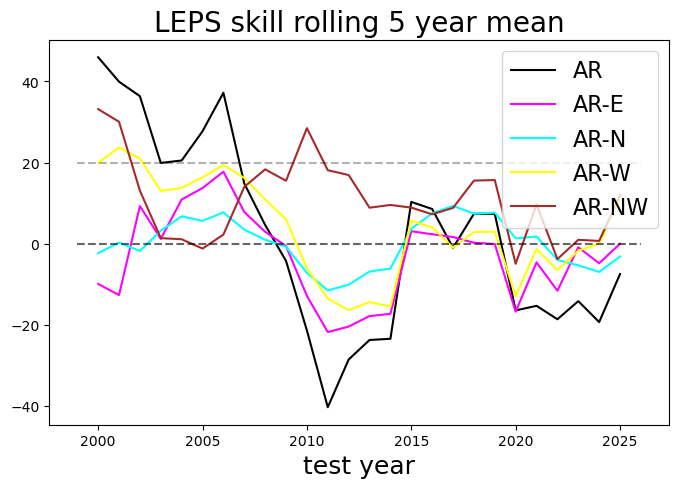

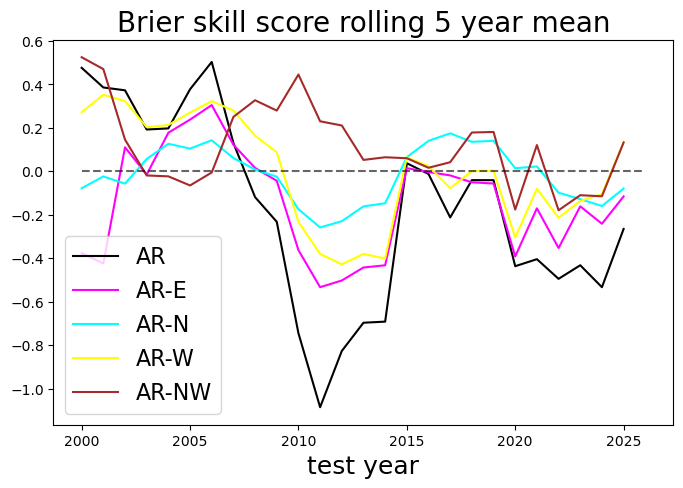

BSS       LEPS
target endyear                     
AR     2020    -1.033230 -42.580012
       2021    -0.967568 -40.258196
       2022    -1.097275 -44.808780
       2023     0.655165  41.288959
       2024    -0.221216 -10.490937
       2025     0.305887  16.703036
AR-E   2020    -1.020721 -42.140609
       2021     0.633156  39.444348
       2022    -1.193219 -48.084931
       2023     0.610013  37.563438
       2024    -0.234669 -11.098069
       2025    -0.391874 -17.961478
AR-N   2020    -0.330542 -15.332374
       2021     0.259663  13.974177
       2022    -0.415744 -18.969009
       2023    -0.279772 -13.109781
       2024    -0.030718  -1.504757
       2025     0.070630   3.615262
AR-W   2020    -0.856500 -36.240810
       2021     0.545280  32.580426
       2022    -0.978888 -40.661198
       2023     0.529449  31.416839
       2024     0.239042  12.784378
       2025     0.332658  18.325142
AR-NW  2020    -0.904580 -37.994240
       2021     0.586242  35.688689
       2022    -1.093467 -44.677232
       2023     0.629548  39.147316
       2024     0.209330  11.097961
       2025     0.332874  18.338368
SPO    2020    -0.088798  -4.326534
       2021     0.027593   1.408804
       2022     0.081114   4.160456
       2023    -0.121465  -5.880607
       2024     0.044945   2.292431
       2025     0.058621   2.994509
SPO-E  2020    -0.303452 -14.151828
       2021     0.259716  13.977270
       2022     0.343590  18.996915
       2023    -0.392910 -18.005365
       2024     0.138982   7.227310
       2025     0.184864   9.732967
SPO-W  2020    -0.518708 -23.220682
       2021     0.390651  21.954673
       2022    -0.653529 -28.575458
       2023     0.401886  22.677470
       2024    -0.111727  -5.419735
       2025    -0.203223  -9.673626

In [9]:
# # Skill. Scroll to bottom to see skill over the past few years.

import analysis,prediction

#1990 was original. Suggest changing this to more recent, last 30 years.
# skill_start_year=1990
skill_start_year=1996
# skill_start_year=1994

tcs_yearly=tcs[tcs.index.month == 9]
#################### 
#### TSCV Loop + bss plot
####################


scores={}
plt.figure(figsize=[9,6])
for target,color in zip(['AR','AR-E','AR-N','AR-W','AR-NW','SPO','SPO-E','SPO-W'],['k','red','blue','green','magenta','cyan','brown','pink']):
# for target,color in zip(['SPO','SPO-E','SPO-W'],['k','magenta','cyan']):    
    scores[target]={'endyear':[],'LEPS skill':[],'BSS':[]}
    for endyear in range(skill_start_year,PREDICTION_YEAR):
        dtEnd = dt.datetime(endyear,9,1)
        Y = tcs_yearly[target].copy()
        X1 = nino_jas[:dtEnd].copy()
        X2 = soi_jas[:dtEnd].copy()
        pred_nino, pred_soi = prediction.combo_method_SKL(X1,X2,Y,prediction_year=endyear)

        Y_pred = (pred_nino+pred_soi)/2.0
        Y_obs = (Y[dtEnd] > Y[:dt.datetime(endyear,4,1)].median())+1
        score = analysis.get_classification_scores(Y_pred,[Y_obs])

        scores[target]['endyear'].append(endyear)
        scores[target]['LEPS skill'].append(float(score['LEPS skill'][0]))
        scores[target]['BSS'].append(score['BSS'])
        #print("DEBUG: %s %d LEPS skill:"%(target,endyear),score['LEPS skill'])
        #print("DEBUG: %s %d BSS skill:"%(target,endyear),score['BSS'])

 

    plt.plot(np.array(scores[target]['endyear']),np.array(scores[target]['BSS'],),
             label=target, color=color)
plt.title("Brier Skill Score")
plt.xlabel('test year')
plt.xlim([skill_start_year,PREDICTION_YEAR])
plt.ylim([-1,1])
plt.legend()
plt.show()

 

#######################
#### Rolling LEPS plot
#######################

 

plt.figure(figsize=[8,5])
for target,color in zip(['AR','AR-E','AR-N','AR-W','AR-NW',],['k','magenta','cyan','yellow','brown']):
# for target,color in zip(['SPO','SPO-E','SPO-W'],['k','magenta','cyan']):    
    # rolling mean
    dfi = pd.DataFrame(scores[target])
    # take rolling mean as new column (column index = 2, doesn't matter)
    dfi.insert(1,'rolling', dfi['LEPS skill'].rolling(window=5).mean(), allow_duplicates=True)
    plt.plot(np.array(dfi['endyear']),np.array(dfi['rolling'],),
             label=target, color=color)
plt.plot([skill_start_year+3,PREDICTION_YEAR],[20,20],'--k', alpha=0.3)
plt.plot([skill_start_year+3,PREDICTION_YEAR],[0,0],'--k', alpha=0.6)
plt.title("LEPS skill rolling 5 year mean", fontsize=20)
plt.xlabel('test year',fontsize=18)
plt.legend(fontsize=16)
#plt.savefig('figures/leps_rolling_mean.png')
plt.show()

 

#######################
#### Rolling BSS plot
#######################
plt.figure(figsize=[8,5])
for target,color in zip(['AR','AR-E','AR-N','AR-W','AR-NW',],['k','magenta','cyan','yellow','brown']):
# for target,color in zip(['SPO','SPO-E','SPO-W'],['k','magenta','cyan']):  
    # rolling mean
    dfi = pd.DataFrame(scores[target])
    # take rolling mean as new column (column index = 2, doesn't matter)
    dfi.insert(1,'rolling BSS', dfi['BSS'].rolling(window=5).mean(), allow_duplicates=True)
    plt.plot(np.array(dfi['endyear']),np.array(dfi['rolling BSS'],),
             label=target, color=color)
plt.plot([skill_start_year+4,PREDICTION_YEAR],[0,0],'--k', alpha=0.6)
plt.title("Brier skill score rolling 5 year mean",fontsize=20)
plt.xlabel('test year',fontsize=18)
plt.legend(fontsize=16)
#plt.savefig('figures/BSS_rolling_mean.png')
plt.show()

 

#######################
#### print last X years of scores
#######################
scores_df=None
scores_df_list=[]
for target in ['AR','AR-E','AR-N','AR-W','AR-NW','SPO','SPO-E','SPO-W']:
    dfi = pd.DataFrame(scores[target])
    dfi['target']=target
    # LEPS skill is already scalar; keep a shorter column name
    dfi['LEPS'] = dfi['LEPS skill']
    dfi.drop(columns=['LEPS skill'],inplace=True)
    scores_df_list.append(dfi)
    dfi.set_index(['target','endyear'],inplace=True)
    # print(dfi)
    if scores_df is None:
        scores_df = dfi
    else:
        scores_df = pd.concat([scores_df,dfi])


# Print the scores since 2020.
#print(scores_df[-3:])
#dfi[-3:]
scores_df.query('endyear >= 2020')


In [10]:
scores_df.query('endyear == 2025')

,,BSS,LEPS
target,endyear,,
AR,2025,0.305887,16.703036
AR-E,2025,-0.391874,-17.961478
AR-N,2025,0.070630,3.615262
AR-W,2025,0.332658,18.325142
AR-NW,2025,0.332874,18.338368
SPO,2025,0.058621,2.994509
SPO-E,2025,0.184864,9.732967
SPO-W,2025,-0.203223,-9.673626


In [11]:
# Print out averaged BS and LEPS since 1970.

region_list = ['AR', 'AR-E', 'AR-N', 'AR-W', 'AR-NW', 'SPO', 'SPO-E', 'SPO-W']
for dfi_index, dfi in enumerate(scores_df_list):
    #print(dfi.iloc[0])
    print(region_list[dfi_index])
    print(dfi.mean())

AR
BSS    -0.092474
LEPS    6.425463
dtype: float64
AR-E
BSS    -0.165422
LEPS   -3.819781
dtype: float64
AR-N
BSS    -0.024457
LEPS   -0.376888
dtype: float64
AR-W
BSS     0.033959
LEPS    5.628122
dtype: float64
AR-NW
BSS      0.153840
LEPS    12.705101
dtype: float64
SPO
BSS     0.039421
LEPS    2.338109
dtype: float64
SPO-E
BSS     0.044793
LEPS    4.286396
dtype: float64
SPO-W
BSS    -0.147868
LEPS   -2.368235
dtype: float64
